# Paper 2 - WGCs

## Data preparation

### Paper 2-specific SQL database subset

In [3]:
import os
# Import the paper-specific paths configuration dataclass
from genomics_config import paths_config, filtering_config, master_config
# Import the specific data preparation function (database subsetting for Paper 2)
from genomics_dataprep import genomics_database_subset

# Create an instance of the paths_config dataclass
paths = paths_config(
    source_dir = r"../dbs", # Raw and pre-processed PNK databases - DB2_standard folder
    source_db = r"../dbs/pnk_db2_filtered.sqlite", # The specific, filtered source database - pnk_db2_filtered
    paper_dir = r"..", # Paper 2-specific files and code
    paper_in_db = r"../dbs/pnk_db2_p2_in.sqlite", # The input database created and used in Paper 2 - pnk_db2_p2_in
    paper_out_db = r"../dbs/pnk_db2_p2_out.sqlite", # The output database created and used in Paper 2 - pnk_db2_p2_out
)

filtering = filtering_config(
    filtering_sql_query="""
        SELECT medical_record_id, patient_id
        FROM medical_records_filtered
        """
        # WHERE gdpr4 = 1
        #   AND gdpr10 = 0
        #   AND medical_record_sequence = 1
)

config = master_config(
    paths=paths,
    filtering=filtering
)

# Create the output directory if it doesn't exist to prevent errors
os.makedirs(config.paths.paper_dir, exist_ok=True)

# Call the data subsetting function
genomics_database_subset(config)

Wrote 17680 rows from medical_records_filtered to medical_records_genomics.
Wrote 347707 rows from measurements_filtered to measurements_genomics.
Data has been saved to ../dbs/pnk_db2_p2_in.sqlite.
Total records: 17680 from 14390 patients.


### Paper 2-specific time-to-event tables

In [ ]:
import os
# Import the paper-specific and analysis-specific configuration dataclasses
from genomics_config import paths_config, timetoevent_config, timetoevent_subsetting_config, master_config
# Import the specific data preparation function (time-to-event table calculations for Paper 2)
from genomics_dataprep import build_timetoevent_table, subset_timetoevent_table

paths = paths_config(
    source_dir = r"c:/Users/Felhasználó/Desktop/Projects/PNK_DB2/genomics_dir/dbs", 
    source_db = r"c:/Users/Felhasználó/Desktop/Projects/PNK_DB2/genomics_dir/dbs/pnk_db2_filtered.sqlite", # copy of the filtered DB stored in the project directory
    paper_dir = r"..", # Paper 2-specific files and code
    paper_in_db = r"c:/Users/Felhasználó/Desktop/Projects/PNK_DB2/genomics_dir/dbs/pnk_db2_genomics_in.sqlite", 
    paper_out_db = r"c:/Users/Felhasználó/Desktop/Projects/PNK_DB2/genomics_dir/dbs/pnk_db2_genomics_out.sqlite", 
)

timetoevent = timetoevent_config(
    # paper_in_db=paths_config.paper_in_db,
    # paper_out_db=paths_config.paper_out_db,
    input_measurements="measurements_filtered",
    input_records="medical_records_filtered",
    output_table="timetoevent_all",
    weight_loss_targets=[5, 10, 15],
    time_windows=[30, 60, 90, 120, 150, 180],
    window_span=10,
    fetch_from_records=[
        "patient_id", "medical_record_id",
        "sex_f", "age_when_creating_record AS age", "height_m",
        "country", "pnk_method",
        "nr_medical_records_patient", "medical_record_sequence", "dietitian_visits", 
        "genomics_sample_id", "gdpr10",
        "genomics_prescription_date", "genomics_purchase_date", 
        "genomics_test_date", "genomics_results_date", 
        # "weight_gain_cause", "weight_gain_cause_en", 
        # "womens_health_and_pregnancy", "mental_health", "family_issues",
        # "medication_disease_injury", "physical_inactivity", "eating_habits", 
        # "schedule", "smoking_cessation", "treatment_discontinuation_or_relapse", "pandemic",
        # "lifestyle_circumstances", "none_of_above", 
    ],
    predictor_columns=[
        "patient_id","medical_record_id",
        "baseline_date", "final_date", # "last_aval_date",
        "country", "pnk_method",        
        "genomics_sample_id", "gdpr10", 
        "genomics_prescription_date", "genomics_purchase_date", 
        "genomics_test_date", "genomics_results_date", 
        "sex_f","age", "height_m", 

        # "weight_gain_cause", "weight_gain_cause_en", 
        # "womens_health_and_pregnancy", "mental_health", "family_issues",
        # "medication_disease_injury", "physical_inactivity", "eating_habits", 
        # "schedule", "smoking_cessation", "treatment_discontinuation_or_relapse", "pandemic",
        # "lifestyle_circumstances", "none_of_above", 
    ], 

    followup_columns=[
        # "patient_id","medical_record_id",
        # "baseline_date","last_aval_date",
        
        "total_followup_days", "instant_dropout", 
        "nr_medical_records_patient", "medical_record_sequence", 
        "dietitian_visits", "nr_total_measurements", "avg_days_between_measurements",
        
        "baseline_weight_kg","final_weight_kg","total_wl_kg","total_wl_%", 
        "baseline_bmi","final_bmi","bmi_reduction", "baseline_fat_%","final_fat_%","total_fat_loss_%",
        "baseline_muscle_%","final_muscle_%","total_muscle_change_%"
    ]
)

config = master_config(
    paths=paths,
    timetoevent=timetoevent,
    timetoevent_subsetting=timetoevent_subsetting
)

build_timetoevent_table(config)


Connecting to source database: c:/Users/Felhasználó/Desktop/Projects/PNK_DB2/genomics_dir/dbs/pnk_db2_filtered.sqlite
Saved 17680 rows to c:/Users/Felhasználó/Desktop/Projects/PNK_DB2/genomics_dir/dbs/pnk_db2_genomics_in.sqlite::timetoevent_all
  - Generated 5 country dummy columns: ['country_be', 'country_ch', 'country_es', 'country_it', 'country_pt']


WARNING: the current filtering for 'no genomics' is based on 'GDPR10=1', not the absence of genomics_sample_id. This leaves 51 records in the cohort that HAVE genomics. This is 51 out of 11 514, but they generally have long follow-ups and may introduce a tiny bias that is unprofessional. 

In [12]:
# Import the paper-specific and analysis-specific configuration dataclasses
from genomics_config import paths_config, timetoevent_subsetting_config, master_config
# Import the specific data preparation function (time-to-event table calculations for Paper 2)
from genomics_dataprep import subset_timetoevent_table

paths = paths_config(
    source_dir = r"c:/Users/Felhasználó/Desktop/Projects/PNK_DB2/genomics_dir/dbs", 
    source_db = r"c:/Users/Felhasználó/Desktop/Projects/PNK_DB2/genomics_dir/dbs/pnk_db2_filtered.sqlite", # copy of the filtered DB stored in the project directory
    paper_dir = r"..", # Paper 2-specific files and code
    paper_in_db = r"c:/Users/Felhasználó/Desktop/Projects/PNK_DB2/genomics_dir/dbs/pnk_db2_genomics_in.sqlite", 
    paper_out_db = r"c:/Users/Felhasználó/Desktop/Projects/PNK_DB2/genomics_dir/dbs/pnk_db2_genomics_out.sqlite", 
)

timetoevent_subsetting = timetoevent_subsetting_config(
    source_table="timetoevent_all",
    definitions={
        "timetoevent_gen_compl": ["genomics_sample_id", ("gdpr10", 1)],
        "timetoevent_gen_compl_first_records": ["genomics_sample_id", ("gdpr10", 1), ("medical_record_sequence", 1)],
        "timetoevent_no_genomics_first_records": [("gdpr10", 0), ("medical_record_sequence", 1)],
    }
)
config = master_config(
    paths=paths,
    timetoevent_subsetting=timetoevent_subsetting
)

# Update config with the new subsetting rules
config.timetoevent_subsetting = timetoevent_subsetting
subset_timetoevent_table(config)


--- Starting Table Subsetting from 'timetoevent_all' ---
  - Saved 3183 rows to table 'timetoevent_gen_compl'
    Filters applied: Existence=['genomics_sample_id'], Values=[('gdpr10', 1)]
  - Saved 2044 rows to table 'timetoevent_gen_compl_first_records'
    Filters applied: Existence=['genomics_sample_id'], Values=[('gdpr10', 1), ('medical_record_sequence', 1)]
  - Saved 11514 rows to table 'timetoevent_no_genomics_first_records'
    Filters applied: Existence=[], Values=[('gdpr10', 0), ('medical_record_sequence', 1)]
--- Table Subsetting Complete ---


## Block I - Comparative explorative analyses of the genomics vs whole cohort, without matching / pruning / adjustments

### EDA of prescribing doctors

⏳ Loading data...

 🏥 PROVIDER & CONTINUITY METRICS
Total Unique Prescribing Doctors: 1168
Total Medical Records: 25879
   Single-Doctor Records: 25300 (97.8%)
   Multi-Doctor Records:  579 (2.2%)

🔍 Deep Dive: Multi-Doctor Records (579 cases)
   - With Genomics:    109 (18.8%)
   - Without Genomics: 470

 📉 GENERATING CHARTS
Displaying 3 separate high-detail figures...


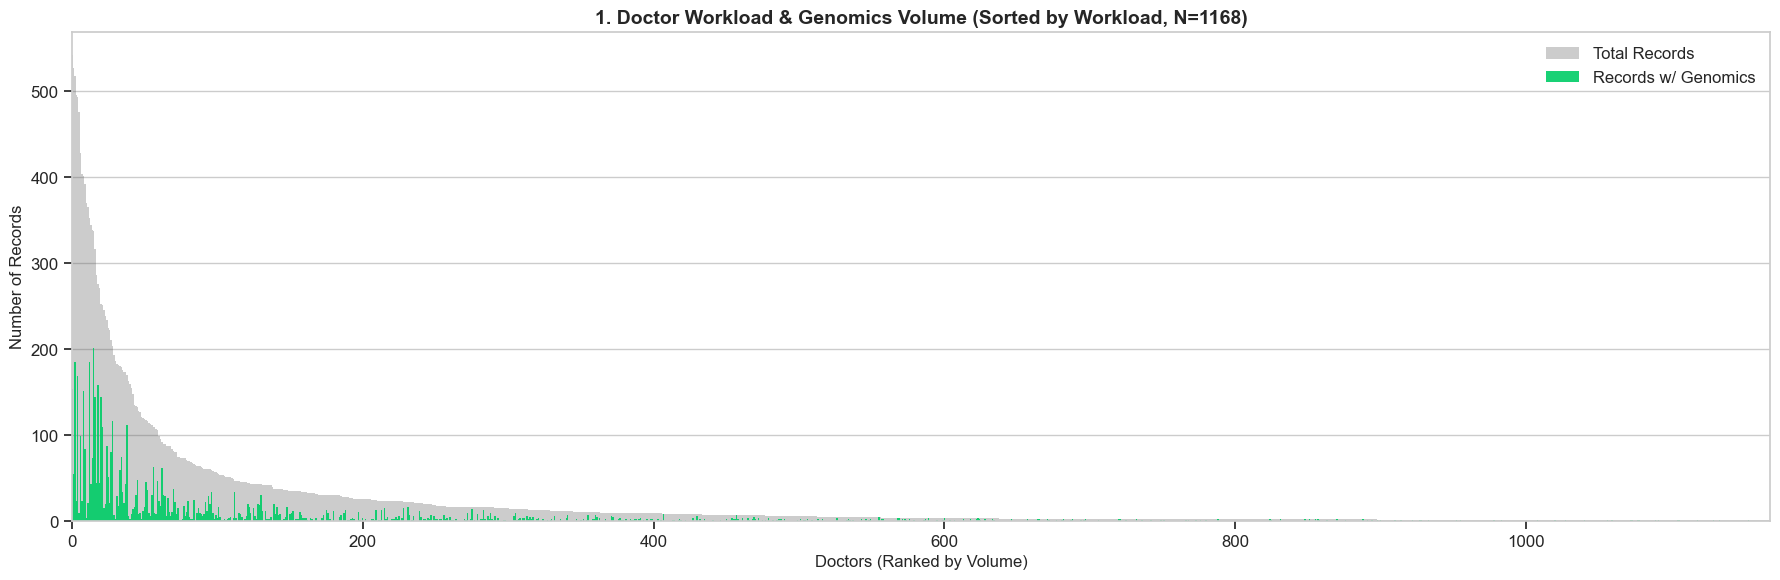

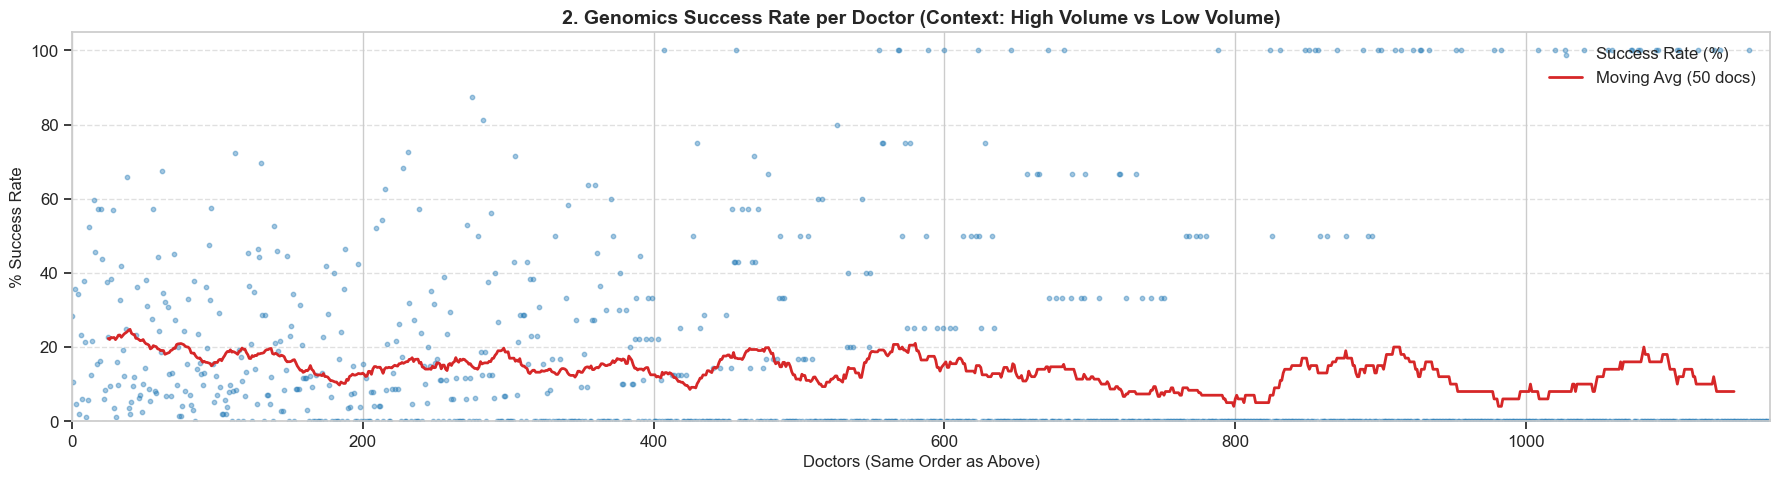

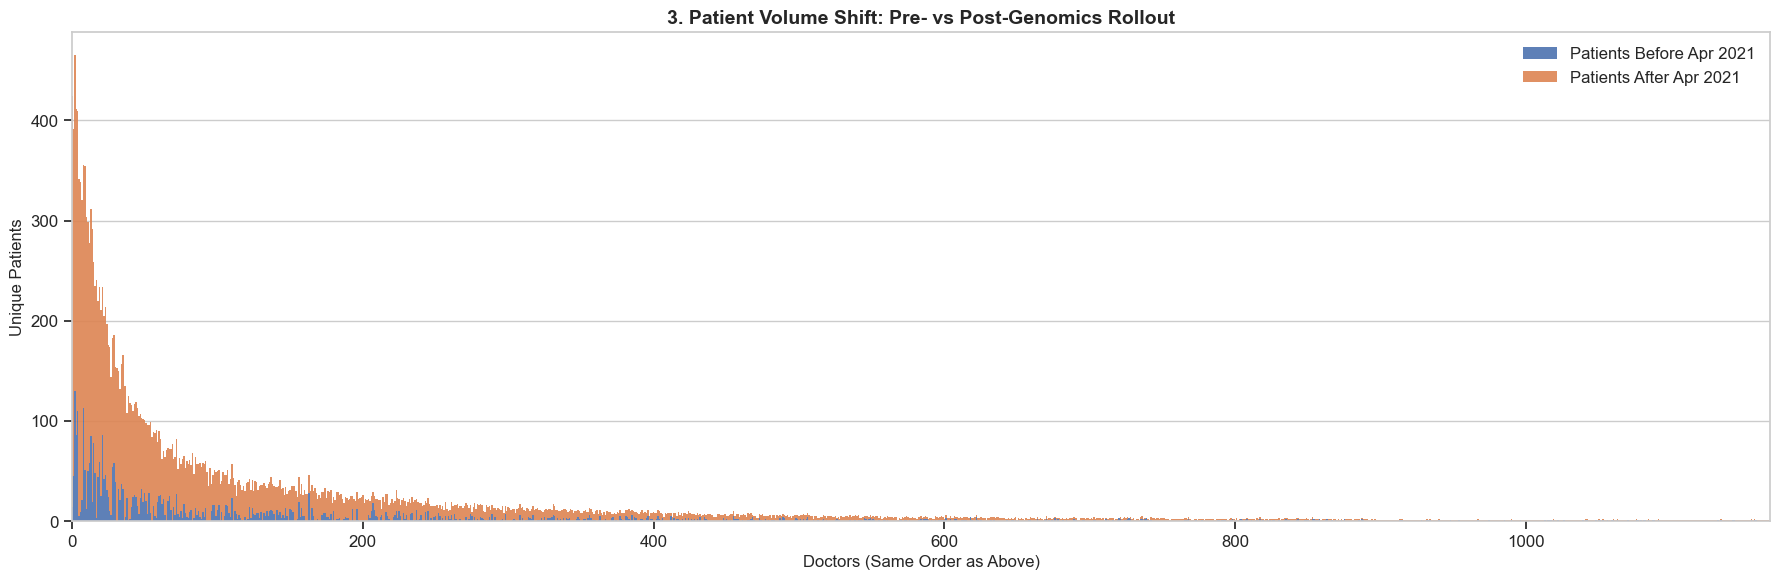


📊 KEY DISTRIBUTION INSIGHTS
   - Top 10 Doctors handle 4678 records (18.1% of total).
   - Doctors with >50% Genomics Rate: 101 doctors.
   - Doctors with 0% Genomics Rate:   722 doctors.


In [5]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import os

# --- Configuration ---
DB_PATH = r"C:\Users\Felhasználó\Desktop\Projects\PNK_DB2\DB2_standard\pnk_db2_standard.sqlite"

def run_analysis():
    # Style settings for high visibility
    plt.style.use('seaborn-v0_8-whitegrid')
    sns.set_context("notebook", font_scale=1.1)
    
    # 1. Load Data
    if not os.path.exists(DB_PATH):
        print(f"❌ Error: Database file not found.")
        return

    print("⏳ Loading data...")
    conn = sqlite3.connect(DB_PATH)
    query = """
    SELECT 
        patient_id, 
        medical_record_id, 
        prescribing_doctor, 
        genomics_results_date,
        prescription_creation_date
    FROM prescriptions_standard
    """
    df = pd.read_sql_query(query, conn)
    conn.close()
    
    # 2. Preprocessing
    df['prescription_creation_date'] = pd.to_datetime(df['prescription_creation_date'], errors='coerce')
    # Filter valid doctors
    df = df[df['prescribing_doctor'].notna() & (df['prescribing_doctor'].astype(str).str.strip() != '')]
    # Boolean for genomics presence
    df['has_genomics'] = df['genomics_results_date'].fillna('').astype(str).str.strip() != ''

    # ==========================
    # 📜 SECTION 1: NUMERIC INSIGHTS
    # ==========================
    print("\n" + "="*50)
    print(" 🏥 PROVIDER & CONTINUITY METRICS")
    print("="*50)
    
    # Unique Doctors
    unique_doctors = df['prescribing_doctor'].unique()
    print(f"Total Unique Prescribing Doctors: {len(unique_doctors)}")
    
    # Continuity (Doctors per Record)
    docs_per_record = df.groupby('medical_record_id')['prescribing_doctor'].nunique()
    total_records = len(docs_per_record)
    mixed_records = docs_per_record[docs_per_record > 1].index
    n_mixed = len(mixed_records)
    
    print(f"Total Medical Records: {total_records}")
    print(f"   Single-Doctor Records: {total_records - n_mixed} ({((total_records-n_mixed)/total_records):.1%})")
    print(f"   Multi-Doctor Records:  {n_mixed} ({(n_mixed/total_records):.1%})")
    
    # Genomics in Mixed Records
    if n_mixed > 0:
        mixed_genomics_status = df[df['medical_record_id'].isin(mixed_records)].groupby('medical_record_id')['has_genomics'].any()
        n_mixed_w_genomics = mixed_genomics_status.sum()
        print(f"\n🔍 Deep Dive: Multi-Doctor Records ({n_mixed} cases)")
        print(f"   - With Genomics:    {n_mixed_w_genomics} ({(n_mixed_w_genomics/n_mixed):.1%})")
        print(f"   - Without Genomics: {n_mixed - n_mixed_w_genomics}")

    # ==========================
    # 📊 SECTION 2: VISUALIZATION
    # ==========================
    
    # --- Prepare Data Frame ---
    # 1. Volume Stats
    doc_stats = df.groupby('prescribing_doctor')['medical_record_id'].nunique().to_frame(name='total_records')
    
    # 2. Genomics Stats
    record_status = df.groupby(['medical_record_id', 'prescribing_doctor'])['has_genomics'].any().reset_index()
    doc_genomics = record_status.groupby('prescribing_doctor')['has_genomics'].sum()
    doc_stats['genomics_records'] = doc_genomics
    doc_stats['genomics_pct'] = (doc_stats['genomics_records'] / doc_stats['total_records']) * 100
    
    # 3. Temporal Stats
    cutoff = pd.Timestamp('2021-04-19')
    df_dates = df[['prescribing_doctor', 'patient_id', 'prescription_creation_date']].dropna(subset=['prescription_creation_date'])
    df_dates['period'] = np.where(df_dates['prescription_creation_date'] >= cutoff, 'after_2021', 'before_2021')
    
    doc_temporal = df_dates.groupby(['prescribing_doctor', 'period'])['patient_id'].nunique().unstack(fill_value=0)
    doc_stats = doc_stats.join(doc_temporal).fillna(0)
    if 'before_2021' not in doc_stats.columns: doc_stats['before_2021'] = 0
    if 'after_2021' not in doc_stats.columns: doc_stats['after_2021'] = 0

    # SORTING: Sort by Total Volume Descending (The "Long Tail")
    doc_stats = doc_stats.sort_values('total_records', ascending=False)
    x_indices = np.arange(len(doc_stats))

    print("\n" + "="*50)
    print(" 📉 GENERATING CHARTS")
    print("="*50)
    print("Displaying 3 separate high-detail figures...")

    # --- FIGURE 1: Workload & Genomics Volume ---
    plt.figure(figsize=(18, 6))
    
    # Plot Total Records (Grey Background) - Use width=1.0 and linewidth=0 for solid block effect
    plt.bar(x_indices, doc_stats['total_records'], color='#595959', alpha=0.3, width=1.0, linewidth=0, label='Total Records')
    
    # Plot Genomics Records (Strong Color Overlay)
    plt.bar(x_indices, doc_stats['genomics_records'], color='#00CC66', alpha=0.9, width=1.0, linewidth=0, label='Records w/ Genomics')
    
    plt.xlim(0, len(doc_stats))
    plt.title(f'1. Doctor Workload & Genomics Volume (Sorted by Workload, N={len(doc_stats)})', fontsize=14, weight='bold')
    plt.ylabel('Number of Records', fontsize=12)
    plt.xlabel('Doctors (Ranked by Volume)', fontsize=12)
    plt.legend(fontsize=12)
    plt.grid(False, axis='x') # Clean look
    plt.tight_layout()
    plt.show()

    # --- FIGURE 2: Genomics Success % ---
    plt.figure(figsize=(18, 5))
    
    # Use Scatter for density + Rolling Average Line
    plt.scatter(x_indices, doc_stats['genomics_pct'], s=10, color='#1f77b4', alpha=0.4, label='Success Rate (%)')
    
    # Moving average trendline (window=50 doctors)
    rolling_avg = doc_stats['genomics_pct'].rolling(window=50, center=True).mean()
    plt.plot(x_indices, rolling_avg, color='#D62728', linewidth=2, label='Moving Avg (50 docs)')
    
    plt.xlim(0, len(doc_stats))
    plt.ylim(0, 105)
    plt.title('2. Genomics Success Rate per Doctor (Context: High Volume vs Low Volume)', fontsize=14, weight='bold')
    plt.ylabel('% Success Rate', fontsize=12)
    plt.xlabel('Doctors (Same Order as Above)', fontsize=12)
    plt.legend(loc='upper right', fontsize=12)
    plt.grid(True, axis='y', linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.show()

    # --- FIGURE 3: Temporal Shift ---
    plt.figure(figsize=(18, 6))
    
    # Stacked Bar (Before = Blue, After = Orange)
    p1 = plt.bar(x_indices, doc_stats['before_2021'], color='#4C72B0', width=1.0, linewidth=0, alpha=0.9, label='Patients Before Apr 2021')
    p2 = plt.bar(x_indices, doc_stats['after_2021'], bottom=doc_stats['before_2021'], color='#DD8452', width=1.0, linewidth=0, alpha=0.9, label='Patients After Apr 2021')

    plt.xlim(0, len(doc_stats))
    plt.title('3. Patient Volume Shift: Pre- vs Post-Genomics Rollout', fontsize=14, weight='bold')
    plt.ylabel('Unique Patients', fontsize=12)
    plt.xlabel('Doctors (Same Order as Above)', fontsize=12)
    plt.legend(fontsize=12)
    plt.grid(False, axis='x')
    plt.tight_layout()
    plt.show()

    # --- EXTRA TEXT STATS ---
    print("\n📊 KEY DISTRIBUTION INSIGHTS")
    print(f"   - Top 10 Doctors handle {doc_stats['total_records'].head(10).sum()} records ({doc_stats['total_records'].head(10).sum()/total_records:.1%} of total).")
    print(f"   - Doctors with >50% Genomics Rate: {len(doc_stats[doc_stats['genomics_pct'] > 50])} doctors.")
    print(f"   - Doctors with 0% Genomics Rate:   {len(doc_stats[doc_stats['genomics_pct'] == 0])} doctors.")

if __name__ == "__main__":
    run_analysis()

### I/1. Genomics vs no genomics cohort comparison

pipeline CRITICISM: test selection for continuous variables is hidden deeply hidden within descriptive_comparisons.py / perform_comparison function. As of 27Jan26, set to Mann-Whitney U test assuming non-normality. If data is found to be normal, switch to Welch's t-test.

In [15]:
# --- Import necessary configs and the new execution function ---
from genomics_config import master_config, paths_config, descriptive_comparisons_config
from descriptive_comparisons import run_descriptive_comparisons

# --- 1. Define Paths ---
paths = paths_config(
    source_dir = r"c:/Users/Felhasználó/Desktop/Projects/PNK_DB2/genomics_dir/dbs", 
    source_db = r"c:/Users/Felhasználó/Desktop/Projects/PNK_DB2/genomics_dir/dbs/pnk_db2_filtered.sqlite", # copy of the filtered DB stored in the project directory
    paper_dir = r"..", # Paper 2-specific files and code
    paper_in_db = r"c:/Users/Felhasználó/Desktop/Projects/PNK_DB2/genomics_dir/dbs/pnk_db2_genomics_in.sqlite", 
    paper_out_db = r"c:/Users/Felhasználó/Desktop/Projects/PNK_DB2/genomics_dir/dbs/pnk_db2_genomics_out.sqlite", 
)
# --- 2. Define the ROW_ORDER once, or customize it per analysis ---
# This can be a global variable in your notebook for convenience

TIME_WINDOWS = [30, 60, 90, 120, 150, 180]
WL_TARGETS = [5, 10, 15]

ROW_ORDER = [
    ("N", "N"),
    # Demographics & baseline anthropom etry
    ("delim_demo", "Demographics and baseline anthropometry"),
    ("country_be", "Belgium (% of patients)"),
    ("country_ch", "Switzerland (% of patients)"),
    ("country_es", "Spain (% of patients)"),
    ("country_it", "Italy (% of patients)"),
    ("country_pt", "Portugal (% of patients)"),
    ("sex_f", "Sex (% of females)"),
    ("age", "Age (years)"),
    ("height_m", "Height (m)"),
    ("baseline_weight_kg", "Baseline weight (kg)"),
    ("baseline_bmi", "Baseline BMI (kg/m²)"),
    ("baseline_fat_%", "Baseline fat mass (%)"),
    ("baseline_muscle_%", "Baseline muscle mass (%)"),
    # Treatment outcomes
    ("delim_outcomes", "Treatment outcomes"),
    ("nr_medical_records_patient", "Number of medical records per patient"),
    ("medical_record_sequence", "Medical record sequence"),
    ("total_followup_days", "Follow-up length (days)"),
    ("dietitian_visits", "Number of visits"),
    ("nr_total_measurements", "Number of total measurements"),
    ("avg_days_between_measurements", "Average measurement frequency (days)"),
    ("final_weight_kg", "Last measured weight (kg)"),
    ("total_wl_kg", "Total weight loss (kg)"),
    ("total_wl_%", "Total weight loss (%)"),
    ("final_bmi", "Final BMI (kg/m²)"),
    ("bmi_reduction", "BMI reduction (kg/m²)"),
    ("final_fat_%", "Last measured fat mass (%)"),
    ("total_fat_loss_%", "Total fat mass loss (%)"),
    ("final_muscle_%", "Last measured muscle mass (%)"),
    ("total_muscle_change_%", "Total muscle mass change (%)"),
    ("instant_dropout", "Instant dropouts (n)"),
]
# Add dynamic time window and WL target variables
for w in TIME_WINDOWS:
    ROW_ORDER += [
        (f"{w}d_dropout", f"{w}-day dropouts (n)"),
        (f"{w}d_wl_%", f"{w}-day weight loss (%)"),
        (f"{w}d_bmi_reduction", f"{w}-day BMI reduction (kg/m²)"),
        (f"{w}d_fat_loss_%", f"{w}-day fat mass loss (%)"),
        (f"{w}d_muscle_change_%", f"{w}-day muscle mass change (%)"),
    ]
for t in WL_TARGETS:
    ROW_ORDER += [
        (f"{t}%_wl_achieved", f"Achieved {t}% weight loss (n)"),
        (f"days_to_{t}%_wl", f"Days to {t}% weight loss"),
    ]

# Define an analysis
analysis1 = descriptive_comparisons_config(
    analysis_name="gen_compl_vs_all",
    input_cohort_name="timetoevent_gen_compl",
    mother_cohort_name="timetoevent_all",
    demographic_output_table="gen_cmpl_dmgrph_strt",
    row_order=ROW_ORDER,
    fdr_correction=True,
    demographic_strata=[
        "age",
        "sex_f",
        "baseline_bmi"
    ]
)

analysis2 = descriptive_comparisons_config(
    analysis_name="gen_compl_vs_gen_compl_first_records",
    input_cohort_name="timetoevent_gen_compl_first_records",
    mother_cohort_name="timetoevent_gen_compl",
    demographic_output_table="gen_cmpl_vs_gen_cmpl_1st",
    row_order=ROW_ORDER,
    fdr_correction=True,
    demographic_strata=[
        "age",
        "sex_f",
        "baseline_bmi"
    ]
)

analysis3 = descriptive_comparisons_config(
    analysis_name="gen_compl_first_records_vs_all",
    input_cohort_name="timetoevent_gen_compl_first_records",
    mother_cohort_name="timetoevent_all",
    demographic_output_table="all_vs_gen_compl_1st",
    row_order=ROW_ORDER,
    fdr_correction=True,
    demographic_strata=[
        "age",
        "sex_f",
        "baseline_bmi"
    ]
)

analysis4 = descriptive_comparisons_config(
    analysis_name="gen_compl_first_records_vs_no_genomics_first_records",
    input_cohort_name="timetoevent_gen_compl_first_records",
    mother_cohort_name="timetoevent_no_genomics_first_records",
    demographic_output_table="nogen_1st_vs_gen_compl_1st",
    row_order=ROW_ORDER,
    fdr_correction=True,
    demographic_strata=[
        "age",
        "sex_f",
        "baseline_bmi"
    ]
)


# --- 5. Assemble the Master Config ---
config = master_config(
    paths=paths,
    # descriptive_comparisons=[analysis1], 
    # descriptive_comparisons=[analysis2],
    # descriptive_comparisons=[analysis3],
    descriptive_comparisons=[analysis4],
)

# --- 6. Execute! ---
# This one function call runs all the analyses you defined.
run_descriptive_comparisons(config)


Starting descriptive comparisons pipeline with 1 analysis configurations.

Executing analysis 1/1: 'gen_compl_first_records_vs_no_genomics_first_records'
  FDR correction: ENABLED
  Loaded data: 2044 input records, 11514 mother records.
Running Demographic Stratification...
  Processing variable 2/67: country_be
  Processing variable 3/67: country_ch
  Processing variable 4/67: country_es
  Processing variable 5/67: country_it
  Processing variable 6/67: country_pt
  Processing variable 7/67: sex_f
  Processing variable 8/67: age
  Processing variable 9/67: height_m
  Processing variable 10/67: baseline_weight_kg
  Processing variable 11/67: baseline_bmi
  Processing variable 12/67: baseline_fat_%
  Processing variable 13/67: baseline_muscle_%
  Processing variable 15/67: nr_medical_records_patient
  Processing variable 16/67: medical_record_sequence
  Processing variable 17/67: total_followup_days
  Processing variable 18/67: dietitian_visits
  Processing variable 19/67: nr_total_meas

### I/2. Visual comparisons

pipeline CRITICISM: some visual elements, especially p-values on violin plots are placed in a way that's covering parts of the plot. Adjusting this can be done manually and in iterations. Not an EDA priority but relevant for image.

on KM plots, follow-up length is too long - we should apply a reasonable cutoff, around 150, max 180 days. 

In [20]:
# --- COMPARATIVE VISUALIZATIONS ---
import os
import sqlite3
import pandas as pd
from genomics_config import paths_config, descriptive_comparisons_config, master_config
from comparative_visualizations import run_comparative_visualizations
# 1. Define Paths (if not already defined)
paths = paths_config(
    source_dir = r"c:/Users/Felhasználó/Desktop/Projects/PNK_DB2/genomics_dir/dbs", 
    source_db = r"c:/Users/Felhasználó/Desktop/Projects/PNK_DB2/genomics_dir/dbs/pnk_db2_filtered.sqlite",
    paper_dir = r"..",
    paper_in_db = r"c:/Users/Felhasználó/Desktop/Projects/PNK_DB2/genomics_dir/dbs/pnk_db2_genomics_in.sqlite", 
    paper_out_db = r"c:/Users/Felhasználó/Desktop/Projects/PNK_DB2/genomics_dir/dbs/pnk_db2_genomics_out.sqlite", 
)
# 2. Get Config (Reuse your existing 'analysis1' config)
# Ideally 'analysis1' is still in memory from your previous cell. 
# If not, ensure it is defined using descriptive_comparisons_config(...)

TIME_WINDOWS = [30, 60, 90, 120, 150, 180]
WL_TARGETS = [5, 10, 15]

ROW_ORDER = [
    ("N", "N"),
    # Demographics & baseline anthropom etry
    ("delim_demo", "Demographics and baseline anthropometry"),
    ("country_be", "Belgium (% of patients)"),
    ("country_ch", "Switzerland (% of patients)"),
    ("country_es", "Spain (% of patients)"),
    ("country_it", "Italy (% of patients)"),
    ("country_pt", "Portugal (% of patients)"),
    ("sex_f", "Sex (% of females)"),
    ("age", "Age (years)"),
    ("height_m", "Height (m)"),
    ("baseline_weight_kg", "Baseline weight (kg)"),
    ("baseline_bmi", "Baseline BMI (kg/m²)"),
    ("baseline_fat_%", "Baseline fat mass (%)"),
    ("baseline_muscle_%", "Baseline muscle mass (%)"),
    # Treatment outcomes
    ("delim_outcomes", "Treatment outcomes"),
    ("nr_medical_records_patient", "Number of medical records per patient"),
    ("medical_record_sequence", "Medical record sequence"),
    ("total_followup_days", "Follow-up length (days)"),
    ("dietitian_visits", "Number of visits"),
    ("nr_total_measurements", "Number of total measurements"),
    ("avg_days_between_measurements", "Average measurement frequency (days)"),
    ("final_weight_kg", "Last measured weight (kg)"),
    ("total_wl_kg", "Total weight loss (kg)"),
    ("total_wl_%", "Total weight loss (%)"),
    ("final_bmi", "Final BMI (kg/m²)"),
    ("bmi_reduction", "BMI reduction (kg/m²)"),
    ("final_fat_%", "Last measured fat mass (%)"),
    ("total_fat_loss_%", "Total fat mass loss (%)"),
    ("final_muscle_%", "Last measured muscle mass (%)"),
    ("total_muscle_change_%", "Total muscle mass change (%)"),
    ("instant_dropout", "Instant dropouts (n)"),
]
# Add dynamic time window and WL target variables
for w in TIME_WINDOWS:
    ROW_ORDER += [
        (f"{w}d_dropout", f"{w}-day dropouts (n)"),
        (f"{w}d_wl_%", f"{w}-day weight loss (%)"),
        (f"{w}d_bmi_reduction", f"{w}-day BMI reduction (kg/m²)"),
        (f"{w}d_fat_loss_%", f"{w}-day fat mass loss (%)"),
        (f"{w}d_muscle_change_%", f"{w}-day muscle mass change (%)"),
    ]
for t in WL_TARGETS:
    ROW_ORDER += [
        (f"{t}%_wl_achieved", f"Achieved {t}% weight loss (n)"),
        (f"days_to_{t}%_wl", f"Days to {t}% weight loss"),
    ]

analysis1 = descriptive_comparisons_config(
    analysis_name="nogen_1st_vs_gen_compl_1st",
    input_cohort_name="timetoevent_gen_compl_first_records",
    mother_cohort_name="timetoevent_no_genomics_first_records",
    demographic_output_table="nogen_1st_vs_gen_compl_1st",
    row_order=ROW_ORDER,
    fdr_correction=True,
    demographic_strata=[
        "age",
        "sex_f",
        "baseline_bmi"
    ]
)

# 3. Load Data directly from DB
# We load the cohorts defined in your analysis config
cohort_name = analysis1.input_cohort_name       # e.g., 'timetoevent_gen_compl'
mother_cohort_name = analysis1.mother_cohort_name # e.g., 'timetoevent_all'
print(f"Loading cohorts: {cohort_name} vs {mother_cohort_name}")
with sqlite3.connect(paths.paper_in_db) as conn:
    df_subset = pd.read_sql(f"SELECT * FROM {cohort_name}", conn)
    df_mother = pd.read_sql(f"SELECT * FROM {mother_cohort_name}", conn)
print(f"Loaded: Subset n={len(df_subset)}, Population n={len(df_mother)}")
# 4. Define Output Directory
output_dir = r"c:/Users/Felhasználó/Desktop/Projects/PNK_DB2/genomics_dir/outputs/nogen_1st_records_vs_gen_1st_records/comparative_plots"
# 5. Run Visualizations
# This will automatically detect variable types from your 'analysis1.row_order' 
# and generate the appropriate plots.
run_comparative_visualizations(df_subset, df_mother, analysis1, output_dir)

Loading cohorts: timetoevent_gen_compl_first_records vs timetoevent_no_genomics_first_records
Loaded: Subset n=2044, Population n=11514

STARTING COMPARATIVE VISUALIZATIONS
Output Directory: c:/Users/Felhasználó/Desktop/Projects/PNK_DB2/genomics_dir/outputs/nogen_1st_records_vs_gen_1st_records/comparative_plots
  ✓ Saved Bar Chart: country_be_stack.png
  ✓ Saved Bar Chart: country_ch_stack.png
  ✓ Saved Bar Chart: country_es_stack.png
  ✓ Saved Bar Chart: country_it_stack.png
  ✓ Saved Bar Chart: country_pt_stack.png
  ✓ Saved Bar Chart: sex_f_stack.png
  ✓ Saved Violin: age_violin.png
  ✓ Saved Violin: height_m_violin.png
  ✓ Saved Violin: baseline_weight_kg_violin.png
  ✓ Saved Violin: baseline_bmi_violin.png
  ✓ Saved Violin: baseline_fat_pct_violin.png
  ✓ Saved Violin: baseline_muscle_pct_violin.png
  ✓ Saved Violin: nr_medical_records_patient_violin.png
  ✓ Saved Violin: medical_record_sequence_violin.png
  ✓ Saved Violin: total_followup_days_violin.png
  ✓ Saved Violin: dietitia

### spaghetti plots

In [1]:
# --- TRAJECTORY VISUALIZATION (FULL SETUP) ---
import sqlite3
import pandas as pd
from trajectory_comparisons import run_trajectory_comparison
from genomics_config import paths_config, descriptive_comparisons_config
# 1. Configuration & Paths
paths = paths_config(
    source_dir = r"c:/Users/Felhasználó/Desktop/Projects/PNK_DB2/genomics_dir/dbs", 
    source_db = r"c:/Users/Felhasználó/Desktop/Projects/PNK_DB2/genomics_dir/dbs/pnk_db2_filtered.sqlite",
    paper_dir = r"..",
    paper_in_db = r"c:/Users/Felhasználó/Desktop/Projects/PNK_DB2/genomics_dir/dbs/pnk_db2_genomics_in.sqlite", 
    paper_out_db = r"c:/Users/Felhasználó/Desktop/Projects/PNK_DB2/genomics_dir/dbs/pnk_db2_genomics_out.sqlite"
)

# 2. Define Cohort Names (Hardcoded based on your previous config)
input_cohort_name = "timetoevent_gen_compl_first_records"
mother_cohort_name = "timetoevent_no_genomics_first_records"
# 3. Load DataFrames from Database
print(f"Loading cohorts from: {paths.paper_in_db}")
with sqlite3.connect(paths.paper_in_db) as conn:
    df_subset = pd.read_sql(f"SELECT * FROM {input_cohort_name}", conn)
    df_mother = pd.read_sql(f"SELECT * FROM {mother_cohort_name}", conn)
print(f"Data Loaded: Subset n={len(df_subset)}, Population n={len(df_mother)}")
# 4. Run Trajectory Analysis
measurements_db = r"c:/Users/Felhasználó/Desktop/Projects/PNK_DB2/genomics_dir/dbs/pnk_db2_filtered.sqlite"
output_dir = r"c:/Users/Felhasználó/Desktop/Projects/PNK_DB2/genomics_dir/outputs/nogen_1st_records_vs_gen_1st_records/comparative_plots"
run_trajectory_comparison(
    df_subset=df_subset, 
    df_mother=df_mother, 
    measurements_db_path=measurements_db, 
    output_dir=output_dir,
    filename="gen_1st_recs_vs_nogen_1st_recs_spaghetti.png",
    cutoff_days=365 
)

Loading cohorts from: c:/Users/Felhasználó/Desktop/Projects/PNK_DB2/genomics_dir/dbs/pnk_db2_genomics_in.sqlite
Data Loaded: Subset n=2044, Population n=11514

STARTING TRAJECTORY COMPARISON (SPAGHETTI PLOTS)
Population Cohort:
  Fetching measurements for 11514 records...
  ✓ Loaded 240314 measurement points.
Subset Cohort:
  Fetching measurements for 2044 records...
  ✓ Loaded 55774 measurement points.
  Applied cutoff: 365 days
  ✓ Saved Trajectory Plot: gen_1st_recs_vs_nogen_1st_recs_spaghetti.png


#### mother-daughter cohort comparison on key outcomes

In [1]:
# ===================================================================
# WGC vs Mother Cohort Lollipop Plot - Enhanced with Variable Ordering
# ===================================================================

import sys
import os
sys.path.append('../scripts')

# Import the lollipop plotting functions
from wgc_mother_cohort_lollipop import (
    main, create_lollipop_from_raw_data, 
    get_available_variables, get_variable_categories
)
import pandas as pd
import numpy as np

# ===================================================================
# Configuration with Variable Ordering Control
# ===================================================================

# Choose your approach
PRESERVE_VARIABLE_ORDER = True  # Set to True to preserve your specified order

# Define your variables in the order you want them to appear in the plot
# NOTE: First variable in list will appear at the TOP of the plot
# Last variable in list will appear at the BOTTOM of the plot
variables_in_desired_order = [
    # Demographics (bottom of plot)
    'Sex (% of females)',
    'Age (years)', 
    'Baseline weight (kg)',
    # 'Baseline BMI (kg/m²)',
    
    # Engagement metrics
    'Follow-up length (days)',
    'Number of visits',
    'Instant dropouts (n)',
    '40-day dropouts (n)',
    '60-day dropouts (n)',
    
    # Weight loss outcomes (top of plot - most important)
    'Total weight loss (%)',
    # 'Total weight loss (kg)',
    # 'BMI reduction (kg/m²)',
    'Achieved 5% weight loss (n)',
    'Days to 5% weight loss',
    'Achieved 10% weight loss (n)',
    'Days to 10% weight loss',
    'Achieved 15% weight loss (n)',
    'Days to 15% weight loss', 
    # 'Total fat mass loss (%)',
    # 'Total muscle mass change (%)'
]

# Main configuration
config = {
    'db_path': "../dbs/pnk_db2_p2_out.sqlite",
    'table_name': "wgc_cmpl_dmgrph_strt",
    'output_plot_path': "../outputs/wgc_mother_cohort_lollipop_ordered.png",
    'output_table_path': "../outputs/wgc_mother_cohort_summary_ordered.csv",
    'variables_to_include': variables_in_desired_order,
    'title': "Key Differences: WGC vs All Patients",
    'figsize': (12, 10),
    'preserve_order': PRESERVE_VARIABLE_ORDER
}

# ===================================================================
# Execute the Plot Generation
# ===================================================================

print("=" * 60)
print("WGC vs Mother Cohort Lollipop Plot Generation")
print("=" * 60)
print(f"Variable ordering: {'PRESERVED (first item = top of plot)' if PRESERVE_VARIABLE_ORDER else 'AUTOMATIC (by magnitude)'}")

try:
    pct_data, summary_table = main(
        db_path=config['db_path'],
        table_name=config['table_name'],
        output_plot_path=config['output_plot_path'],
        output_table_path=config['output_table_path'],
        variables_to_include=config['variables_to_include'],
        title=config['title'],
        figsize=config['figsize'],
        preserve_order=config['preserve_order']
    )
    
    print("\n" + "=" * 60)
    print("RESULTS SUMMARY")
    print("=" * 60)
    
    # Show variables in the order they appear in the plot (top to bottom)
    print(f"\nVariables in plot order (TOP to BOTTOM):")
    for i, (_, row) in enumerate(pct_data.iterrows(), 1):
        significance = row['significance']
        pct_change = row['percent_change']
        print(f"{i:2d}. {row['variable']}: {pct_change:+.1f}% {significance}")
    
    # Display key findings
    significant_vars = pct_data[pct_data['significance'].str.contains('\*', na=False)]
    print(f"\nStatistically significant differences ({len(significant_vars)} total):")
    
    for _, row in significant_vars.iterrows():
        print(f"  {row['variable']}: {row['percent_change']:+.1f}% {row['significance']}")
    
    # Show largest absolute differences
    print(f"\nLargest absolute differences:")
    largest_diffs = pct_data.reindex(pct_data['percent_change'].abs().sort_values(ascending=False).index)
    
    for _, row in largest_diffs.head(5).iterrows():
        print(f"  {row['variable']}: {row['percent_change']:+.1f}% {row['significance']}")
    
    print(f"\nPlot saved to: {config['output_plot_path']}")
    print(f"Summary table saved to: {config['output_table_path']}")
    
    # Display summary statistics
    print(f"\nSummary Statistics:")
    print(f"  Total variables analyzed: {len(pct_data)}")
    print(f"  Significant differences: {len(significant_vars)}")
    print(f"  Variables with >5% change: {len(pct_data[pct_data['percent_change'].abs() > 5])}")
    print(f"  Variables with >10% change: {len(pct_data[pct_data['percent_change'].abs() > 10])}")

except Exception as e:
    print(f"Error generating lollipop plot: {str(e)}")
    import traceback
    traceback.print_exc()

print("\n" + "=" * 60)
print("Plot generation complete!")
print("=" * 60)

<>:100: SyntaxWarning: invalid escape sequence '\*'
<>:100: SyntaxWarning: invalid escape sequence '\*'
C:\Users\Felhasználó\AppData\Local\Temp\ipykernel_28944\1291606756.py:100: SyntaxWarning: invalid escape sequence '\*'
  significant_vars = pct_data[pct_data['significance'].str.contains('\*', na=False)]


WGC vs Mother Cohort Lollipop Plot Generation
Variable ordering: PRESERVED (first item = top of plot)
Generating WGC vs Mother Cohort Lollipop Plot...
Extracting comparison data...
Sample sizes - WGC cohort: 2463, Mother cohort: 17680
Calculating percentage changes...
Filtered to 15 requested variables (order preserved)
Found 15 variables for comparison:
  Sex (% of females): +3.5% **
  Age (years): -2.0% **
  Baseline weight (kg): -0.6% 
  Follow-up length (days): +2.8% 
  Number of visits: +26.2% **
  Instant dropouts (n): -18.0% *
  40-day dropouts (n): -8.5% **
  60-day dropouts (n): -4.8% *
  Total weight loss (%): +6.1% **
  Achieved 5% weight loss (n): +3.2% **
  Days to 5% weight loss: -5.6% **
  Achieved 10% weight loss (n): +8.6% **
  Days to 10% weight loss: -3.4% 
  Achieved 15% weight loss (n): +9.3% **
  Days to 15% weight loss: +0.3% 
Creating lollipop plot...
Preserving variable order as specified (reversed for top-to-bottom display)
Lollipop plot saved to: ../outputs/w

### I/2. Influence of weight gain causes in weight loss-related predictions

#### I/2.3. Regression analyses

##### I/2.3. logistic - outcomes

In [ ]:
# IMPORTS 
import os
import pandas as pd
from regressions_inference import (
    load_data, 
    generate_logreg_scenarios,
    run_logreg_pipeline
)

# I/O databases
INPUT_DB = r"C:\Users\Felhasználó\Desktop\Projects\PNK_DB2\paper2_dir\pnk_db2_p2_in.sqlite"
OUTPUT_DB = r"C:\Users\Felhasználó\Desktop\Projects\PNK_DB2\paper2_dir\pnk_db2_p2_out.sqlite"

# Uncomment I/O tables to use

INPUT_TABLE = "timetoevent_wgc_compl"
OUTPUT_TABLE = "lg_outcms_wgc_cmpl"

# INPUT_TABLE = "timetoevent_wgc_gen_compl"
# OUTPUT_TABLE = "lg_outcms_wgc_gen_cmpl"

# Load once for scenario generation
df_all = load_data(INPUT_DB, INPUT_TABLE)

outcome_types = [
    'target_wl',
    'dropout'
]
time_windows = [
    40, 
    60, 
    80, 
    'total'  # Can also use total follow-up time
]
target_percentages = [
    5, 
    10, 
    15
]
main_predictors = [
        "womens_health_and_pregnancy",
        "mental_health",
        "family_issues",
        "medication_disease_injury",
        "physical_inactivity",
        "eating_habits",
        "schedule",
        "smoking_cessation",
        "treatment_discontinuation_or_relapse",
        "pandemic",
        "lifestyle_circumstances",
        "none_of_above"
]

adjustment_sets = [
    ([], "unadjusted"),
    (['age', 'sex_f', 'baseline_bmi'], "adjusted")
]

LOGREG_SCENARIOS = generate_logreg_scenarios(
    outcome_types, time_windows, target_percentages, main_predictors, adjustment_sets,
    input_table=INPUT_TABLE, df_all=df_all
)

run_logreg_pipeline(INPUT_DB, INPUT_TABLE, LOGREG_SCENARIOS, OUTPUT_TABLE, OUTPUT_DB)

##### I/2.3. linear - outcomes

In [ ]:
# IMPORTS 
import os
import pandas as pd
from regressions_inference import (
    load_data, 
    generate_linreg_scenarios,
    run_linreg_pipeline
)

# I/O databases
INPUT_DB = r"C:\Users\Felhasználó\Desktop\Projects\PNK_DB2\paper2_dir\pnk_db2_p2_in.sqlite"
OUTPUT_DB = r"C:\Users\Felhasználó\Desktop\Projects\PNK_DB2\paper2_dir\pnk_db2_p2_out.sqlite"

# Uncomment I/O tables to use

INPUT_TABLE = "timetoevent_wgc_compl"
OUTPUT_TABLE = "ln_outcms_wgc_compl"

# INPUT_TABLE = "timetoevent_wgc_gen_compl"
# OUTPUT_TABLE = "ln_outcms_wgc_gen_compl"

# Load once for scenario generation
df_all = load_data(INPUT_DB, INPUT_TABLE)

outcome_types = ['weight_change', 'fat_change', 'muscle_change']
time_windows = [40, 60, 80, 'total']
main_predictors = [
        "womens_health_and_pregnancy",
        "mental_health",
        "family_issues",
        "medication_disease_injury",
        "physical_inactivity",
        "eating_habits",
        "schedule",
        "smoking_cessation",
        "treatment_discontinuation_or_relapse",
        "pandemic",
        "lifestyle_circumstances",
        "none_of_above"
]
adjustment_sets = [
    ([], "unadjusted"),
    (['age', 'sex_f', 'baseline_bmi'], "adjusted")
]

LINREG_SCENARIOS = generate_linreg_scenarios(
    outcome_types, time_windows, main_predictors, adjustment_sets,
    input_table=INPUT_TABLE, df_all=df_all
)

run_linreg_pipeline(INPUT_DB, INPUT_TABLE, LINREG_SCENARIOS, OUTPUT_TABLE, OUTPUT_DB)

##### I/2.3. linear - adherence

In [ ]:
# IMPORTS
import os
import pandas as pd
from regressions_inference import (
    load_data, 
    generate_adherence_scenarios,
    run_adherence_linreg_pipeline
)

# I/O databases
INPUT_DB = r"C:\Users\Felhasználó\Desktop\Projects\PNK_DB2\paper2_dir\pnk_db2_p2_in.sqlite"
OUTPUT_DB = r"C:\Users\Felhasználó\Desktop\Projects\PNK_DB2\paper2_dir\pnk_db2_p2_out.sqlite"

# Uncomment I/O tables to use
INPUT_TABLE = "timetoevent_wgc_compl"
OUTPUT_TABLE = "ln_adher_wgc_compl"

# INPUT_TABLE = "timetoevent_wgc_gen_compl"
# OUTPUT_TABLE = "ln_adher_wgc_gen_compl"

# Load once for scenario generation
df_all = load_data(INPUT_DB, INPUT_TABLE)

adherence_outcomes = [
    'total_followup_days',
    'dietitian_visits',
    'nr_total_measurements',
    'avg_days_between_measurements'
    # days_to_X%_wl handled separately
]
target_percentages = [5, 10, 15]
main_predictors = [
        "womens_health_and_pregnancy",
        "mental_health",
        "family_issues",
        "medication_disease_injury",
        "physical_inactivity",
        "eating_habits",
        "schedule",
        "smoking_cessation",
        "treatment_discontinuation_or_relapse",
        "pandemic",
        "lifestyle_circumstances",
        "none_of_above"
]
adjustment_sets = [
    ([], "unadjusted"),
    (['age', 'sex_f', 'baseline_bmi'], "adjusted")
]

ADHERENCE_SCENARIOS = generate_adherence_scenarios(
    target_percentages,
    main_predictors,
    adjustment_sets,
    input_table=INPUT_TABLE,
    df_all=df_all,
    extra_outcomes=adherence_outcomes
)

run_adherence_linreg_pipeline(INPUT_DB, INPUT_TABLE, ADHERENCE_SCENARIOS, OUTPUT_TABLE, OUTPUT_DB)

# Misc

### SQL to Excel

In [3]:
%pip install openpyxl

  Using cached openpyxl-3.1.5-py2.py3-none-any.whl.metadata (2.5 kB)
  Using cached et_xmlfile-2.0.0-py3-none-any.whl.metadata (2.7 kB)
Using cached openpyxl-3.1.5-py2.py3-none-any.whl (250 kB)
Using cached et_xmlfile-2.0.0-py3-none-any.whl (18 kB)
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.3.1 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


list tables

In [16]:
import pandas as pd
import os
import sqlite3

db_directory = "C:\\Users\\Felhasználó\\Desktop\\Projects\\PNK_DB2\\genomics_dir\\dbs"  # Paper 2-specific files and code
db_path = os.path.join(db_directory, "pnk_db2_genomics_out.sqlite")

with sqlite3.connect(db_path) as conn:
    tables = pd.read_sql_query("SELECT name FROM sqlite_master WHERE type='table';", conn)
    print('Tables in the database:')
    for name in tables['name']:
        print(f'"{name}",')

Tables in the database:
"gen_cmpl_dmgrph_strt",
"gen_cmpl_vs_gen_cmpl_1st",
"all_vs_gen_compl_1st",
"nogen_vs_gen_compl_1st",
"nogen_1st_vs_gen_compl_1st",


In [17]:
import sqlite3
import pandas as pd
import os

db_directory = "C:\\Users\\Felhasználó\\Desktop\\Projects\\PNK_DB2\\genomics_dir\\dbs"  # Paper 2-specific files and code
output_directory = "C:\\Users\\Felhasználó\\Desktop\\Projects\\PNK_DB2\\genomics_dir\\outputs"  # Paper 2-specific files and code

# Define the output Excel file path
DB_PATH = os.path.join(db_directory, "pnk_db2_genomics_out.sqlite")
output_excel_path = os.path.join(output_directory, 'genomics_vs_all_28Jan26.xlsx')

# Define which tables to write to Excel (modify this list as needed)
tables_to_write = [
"nogen_1st_vs_gen_compl_1st",
]

# Alternative: Set to None to export all tables (original behavior)
# tables_to_write = None

# Connect to the SQLite database
with sqlite3.connect(DB_PATH) as conn:
    # Get the list of all tables in the database
    query = "SELECT name FROM sqlite_master WHERE type='table';"
    all_tables = pd.read_sql_query(query, conn)['name'].tolist()
    
    # Determine which tables to export
    if tables_to_write is None:
        # Export all tables (original behavior)
        tables_to_export = all_tables
        print(f"Exporting all {len(tables_to_export)} tables to Excel...")
    else:
        # Export only specified tables
        tables_to_export = [table for table in tables_to_write if table in all_tables]
        missing_tables = [table for table in tables_to_write if table not in all_tables]
        
        if missing_tables:
            print(f"Warning: The following tables were not found in the database: {missing_tables}")
        
        print(f"Exporting {len(tables_to_export)} selected tables to Excel...")
        print(f"Tables to export: {tables_to_export}")
    
    # Create a Pandas Excel writer
    with pd.ExcelWriter(output_excel_path, engine='openpyxl') as writer:
        # Loop through each selected table and save it as a sheet in the Excel file
        for table in tables_to_export:
            try:
                df = pd.read_sql_query(f"SELECT * FROM {table}", conn)
                # Truncate sheet name if too long (Excel limit is 31 characters)
                sheet_name = table[:31] if len(table) > 31 else table
                df.to_excel(writer, sheet_name=sheet_name, index=False)
                print(f"  ✓ Exported table '{table}' ({len(df)} rows)")
            except Exception as e:
                print(f"  ✗ Error exporting table '{table}': {e}")

print(f"\nDatabase export completed. Excel file saved at: {output_excel_path}")


Exporting 1 selected tables to Excel...
Tables to export: ['nogen_1st_vs_gen_compl_1st']
  ✓ Exported table 'nogen_1st_vs_gen_compl_1st' (67 rows)

Database export completed. Excel file saved at: C:\Users\Felhasználó\Desktop\Projects\PNK_DB2\genomics_dir\outputs\genomics_vs_all_28Jan26.xlsx


### SQL table listing and deletion

list tables

In [18]:
import pandas as pd
import os
import sqlite3

db_directory = "C:\\Users\\Felhasználó\\Desktop\\Projects\\PNK_DB2\\genomics_dir\\dbs"  # Paper 2-specific files and code
db_path = os.path.join(db_directory, "pnk_db2_genomics_out.sqlite")

with sqlite3.connect(db_path) as conn:
    tables = pd.read_sql_query("SELECT name FROM sqlite_master WHERE type='table';", conn)
    print('Tables in the database:')
    for name in tables['name']:
        print(f'"{name}",')

Tables in the database:
"gen_cmpl_dmgrph_strt",
"gen_cmpl_vs_gen_cmpl_1st",
"all_vs_gen_compl_1st",
"nogen_vs_gen_compl_1st",
"nogen_1st_vs_gen_compl_1st",


del tables

In [19]:
import sqlite3
import os

db_directory = "C:\\Users\\Felhasználó\\Desktop\\Projects\\PNK_DB2\\genomics_dir\\dbs"  # Paper 2-specific files and code
db_path = os.path.join(db_directory, "pnk_db2_genomics_out.sqlite")

# List of tables to delete
tables_to_delete = [
    "nogen_vs_gen_compl_1st",
]

with sqlite3.connect(db_path) as conn:
    cursor = conn.cursor()
    for table in tables_to_delete:
        cursor.execute(f"DROP TABLE IF EXISTS {table}")
    conn.commit()
print("Selected tables deleted from the defined database.")

Selected tables deleted from the defined database.


### SQL table column deletion

In [ ]:
import sqlite3

paper2_directory = "C:\\Users\\Felhasználó\\Desktop\\Projects\\PNK_DB2\\paper2_dir"  # Paper 2-specific files and code
db_path = os.path.join(paper2_directory, "pnk_db2_p2_in.sqlite")

# Get the table name
with sqlite3.connect(db_path) as conn:
    table_name = conn.execute("SELECT name FROM sqlite_master WHERE type='table';").fetchone()[0]
    # Get all columns
    columns = [row[1] for row in conn.execute(f"PRAGMA table_info([{table_name}]);")]
    # Find index of 'weight_gain_cause_en'
    idx = columns.index('weight_gain_cause_en')
    # Columns to keep (up to and including 'weight_gain_cause_en')
    keep_cols = columns[:idx+1]
    # Columns to drop (after 'weight_gain_cause_en')
    drop_cols = columns[idx+1:]

    if drop_cols:
        # Build new table schema
        col_defs = ", ".join([
            f"{row[1]} {row[2]}"
            for row in conn.execute(f"PRAGMA table_info([{table_name}]);")
            if row[1] in keep_cols
        ])
        new_table = f"{table_name}_tmp"

        # Create new table
        conn.execute(f"CREATE TABLE [{new_table}] ({col_defs});")
        # Copy data
        conn.execute(f"INSERT INTO [{new_table}] SELECT {', '.join(keep_cols)} FROM [{table_name}];")
        # Drop old table
        conn.execute(f"DROP TABLE [{table_name}];")
        # Rename new table
        conn.execute(f"ALTER TABLE [{new_table}] RENAME TO [{table_name}];")
        conn.commit()
        print(f"Columns after '{keep_cols[-1]}' have been deleted from '{table_name}'.")
    else:
        print("No columns to delete after 'weight_gain_cause_en'.")

In [ ]:
import sqlite3
import os

db_path = os.path.join(paper1_directory, "pnk_db2_p1.sqlite")
table_name = "timetoevent_all"
col_to_delete = "genomics_sample_id"

with sqlite3.connect(db_path) as conn:
    # Get all columns
    columns = [row[1] for row in conn.execute(f"PRAGMA table_info([{table_name}]);")]
    if col_to_delete not in columns:
        print(f"Column '{col_to_delete}' not found in '{table_name}'. No action taken.")
    else:
        keep_cols = [col for col in columns if col != col_to_delete]
        col_defs = ", ".join([
            f"{row[1]} {row[2]}"
            for row in conn.execute(f"PRAGMA table_info([{table_name}]);")
            if row[1] in keep_cols
        ])
        tmp_table = f"{table_name}_tmp"
        # Create new table without the column
        conn.execute(f"CREATE TABLE [{tmp_table}] ({col_defs});")
        # Copy data
        conn.execute(f"INSERT INTO [{tmp_table}] SELECT {', '.join(keep_cols)} FROM [{table_name}];")
        # Drop old table and rename new
        conn.execute(f"DROP TABLE [{table_name}];")
        conn.execute(f"ALTER TABLE [{tmp_table}] RENAME TO [{table_name}];")
        conn.commit()
        print(f"Column '{col_to_delete}' deleted from '{table_name}'.")

### DW/SQL queries

In [1]:
import sqlite3
import pandas as pd

db_path = r"C:\Users\Felhasználó\Desktop\Projects\PNK_DB2\genomics_dir\dbs\pnk_db2_filtered.sqlite"
table_name = "alleles_filtered"

with sqlite3.connect(db_path) as conn:
    df = pd.read_sql_query(f"SELECT * FROM {table_name}", conn)

unique_patient_ids = df['patient_id'].nunique()
print(f"Number of unique values in 'patient_id': {unique_patient_ids}")

Number of unique values in 'patient_id': 2396


In [ ]:
df